# Overlaid Precision-Recall Curves — All Models
Reuses the cached prediction probabilities -- no models, no GPU needed.
Computes one MICRO-averaged precision-recall curve per model (aggregating
all 12 classes into one binary problem per model), and overlays all 7
(6 single models + proposed ensemble) on a single paper-sized figure.
PR curves are more sensitive to class imbalance than ROC curves, which
matters here since the test set is not perfectly balanced.

## Cell 1 — Setup + load cached predictions

In [1]:
import numpy as np
import pandas as pd
import json as jsonlib
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

from google.colab import drive
drive.mount('/content/drive')

cache = '/content/drive/MyDrive/thesis_ensemble_outputs/significance_test_cache'

pred_swin = np.load(f'{cache}/pred_swin.npy')
pred_vit = np.load(f'{cache}/pred_vit.npy')
pred_resnet = np.load(f'{cache}/pred_resnet.npy')
pred_densenet = np.load(f'{cache}/pred_densenet.npy')
pred_efficientnet = np.load(f'{cache}/pred_efficientnet.npy')
pred_levit = np.load(f'{cache}/pred_levit.npy')
ensemble_probs = np.load(f'{cache}/ensemble_probs.npy')
true_labels = np.load(f'{cache}/true_labels.npy')
with open(f'{cache}/class_names.json') as f:
    class_names = jsonlib.load(f)

num_classes = len(class_names)
y_true_bin = label_binarize(true_labels, classes=range(num_classes))
print("Loaded. Test set size:", len(true_labels), "| Classes:", num_classes)

Mounted at /content/drive
Loaded. Test set size: 2538 | Classes: 12


## Cell 2 — Compute micro-averaged PR curve + Average Precision for each model

In [2]:
all_models = {
    "Swin": pred_swin,
    "ViT": pred_vit,
    "LeViT": pred_levit,
    "ResNet50": pred_resnet,
    "DenseNet121": pred_densenet,
    "EfficientNetB0": pred_efficientnet,
    "Proposed Ensemble": ensemble_probs,
}

pr_data = {}
ap_rows = []
for name, probs in all_models.items():
    precision, recall, _ = precision_recall_curve(y_true_bin.ravel(), probs.ravel())
    ap = average_precision_score(y_true_bin, probs, average='micro')
    pr_data[name] = (recall, precision, ap)
    ap_rows.append({"Model": name, "Average Precision (micro)": round(ap, 4)})

ap_df = pd.DataFrame(ap_rows).sort_values("Average Precision (micro)", ascending=False)
print(ap_df.to_string(index=False))

output_folder = '/content/drive/MyDrive/thesis_ensemble_outputs'
ap_df.to_csv(f'{output_folder}/average_precision_summary.csv', index=False)
print(f"\nSaved to: {output_folder}/average_precision_summary.csv")

            Model  Average Precision (micro)
Proposed Ensemble                     0.9987
             Swin                     0.9984
              ViT                     0.9980
   EfficientNetB0                     0.9972
         ResNet50                     0.9971
      DenseNet121                     0.9955
            LeViT                     0.9908

Saved to: /content/drive/MyDrive/thesis_ensemble_outputs/average_precision_summary.csv


## Cell 3 — Overlaid PR curve figure
Compact, paper-sized (adjust figsize for your journal's column width).

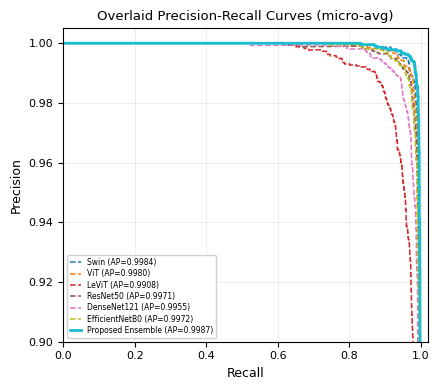

Saved to: /content/drive/MyDrive/thesis_ensemble_outputs/pr_curve_overlaid.png


In [3]:
fig, ax = plt.subplots(figsize=(4.5, 4))
colors = plt.cm.tab10(np.linspace(0, 1, len(pr_data)))

# sort so the proposed ensemble draws last / on top, easiest to spot
ordered_names = [n for n in pr_data if n != "Proposed Ensemble"] + ["Proposed Ensemble"]

for i, name in enumerate(ordered_names):
    recall, precision, ap = pr_data[name]
    lw = 2.0 if name == "Proposed Ensemble" else 1.1
    style = '-' if name == "Proposed Ensemble" else '--'
    ax.plot(recall, precision, linewidth=lw, linestyle=style, color=colors[i],
            label=f"{name} (AP={ap:.4f})")

ax.set_xlabel('Recall', fontsize=9)
ax.set_ylabel('Precision', fontsize=9)
ax.set_title('Overlaid Precision-Recall Curves (micro-avg)', fontsize=9.5)
ax.tick_params(labelsize=8)
ax.legend(fontsize=5.5, loc='lower left', framealpha=0.9, handlelength=1.4, labelspacing=0.3)
ax.grid(alpha=0.3, linewidth=0.5)
ax.set_xlim(0, 1.02)
ax.set_ylim(0.9, 1.005)   # zoomed -- these models are all very high-performing

plt.tight_layout()
plt.savefig(f'{output_folder}/pr_curve_overlaid.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved to: {output_folder}/pr_curve_overlaid.png")